## Boilerplate

In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [4]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [7]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    # criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [8]:
RANDOM_SEED = 42

## try it on 50% unlabeled

In [28]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [29]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
upgrade_model_50, criterion, optimizer = default_setup()
upgrade_history_50 = train_loop_bcnn_soft_pseudo_label(upgrade_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20, alpha=0.1, beta=1.0, num_samples=10)

  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  4.41it/s]


Epoch 1/20 | Train NLL: 1.4688 | Train KL (avg/batch): 0.9019 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 1.4001 | Val AUC Macro: 0.5089 | Val AUC Global: 0.8697


100%|██████████| 8/8 [00:01<00:00,  4.35it/s]


Epoch 2/20 | Train NLL: 1.3245 | Train KL (avg/batch): 0.9017 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 1.4033 | Val AUC Macro: 0.4989 | Val AUC Global: 0.8735


...

Epoch 18/20 | Train NLL: 0.9059 | Train KL (avg/batch): 0.8947 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9905 | Val AUC Macro: 0.8233 | Val AUC Global: 0.9320


100%|██████████| 8/8 [00:01<00:00,  4.18it/s]


Epoch 19/20 | Train NLL: 0.9112 | Train KL (avg/batch): 0.8940 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9447 | Val AUC Macro: 0.8172 | Val AUC Global: 0.9326


100%|██████████| 8/8 [00:01<00:00,  4.21it/s]


Epoch 20/20 | Train NLL: 0.9009 | Train KL (avg/batch): 0.8934 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9535 | Val AUC Macro: 0.8355 | Val AUC Global: 0.9314


In [32]:
best_upgrade_50_history = max(upgrade_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_50_history['epoch']} | Val AUC Macro: {best_upgrade_50_history['val_auc_macro']:.4f}")

best_upgrade_model_50 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_50.load_state_dict(best_upgrade_50_history['model_state'])

Best Epoch: 17 | Val AUC Macro: 0.8359


<All keys matched successfully>

In [33]:
test_results_upgrade_50 = evaluate_bayesian(best_upgrade_model_50, test_loader, device='cpu')
test_results_upgrade_50

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.45it/s]

preds: [5 1 5 ... 5 5 5]


{'macro_auc': 0.8258242433076036,
 'global_auc': 0.9320157420248216,
 'nll': np.float32(0.92536724),
 'per_class_auc': [0.8656055136199541,
  0.8540626627055832,
  0.8240285204991088,
  0.8639275216075111,
  0.7903952328466529,
  0.8468504892051426,
  0.7358997626692727],
 'confusion_matrix': array([[0.        , 0.01515152, 0.24242424, 0.        , 0.        ,
         0.74242424, 0.        ],
        [0.        , 0.00970874, 0.11650485, 0.        , 0.        ,
         0.87378641, 0.        ],
        [0.        , 0.00454545, 0.15      , 0.        , 0.        ,
         0.84545455, 0.        ],
        [0.        , 0.04347826, 0.17391304, 0.        , 0.        ,
         0.7826087 , 0.        ],
        [0.        , 0.0044843 , 0.03139013, 0.        , 0.        ,
         0.96412556, 0.        ],
        [0.        , 0.        , 0.00894855, 0.        , 0.        ,
         0.99105145, 0.        ],
        [0.        , 0.        , 0.06896552, 0.        , 0.        ,
         0.93103448,

In [34]:
with torch.no_grad():
    best_upgrade_model_50.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_upgrade_model_50.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:02<00:00,  2.90it/s]

Percentage of predictions that are class 5: 95.9%


In [35]:
best_upgrade_model_50.eval()
all_pseudo_labels = []
with torch.no_grad():
    for images, labels in train_ssl_loader_50:
        unlabeled_mask = (labels == -1).squeeze()
        inputs_unlabeled = images[unlabeled_mask]
        if inputs_unlabeled.size(0) > 0:
            avg_probs = best_upgrade_model_50.average_probs(inputs_unlabeled, num_samples=10)
            all_pseudo_labels.append(avg_probs)

all_pseudo_labels = torch.cat(all_pseudo_labels)
print(f"Mean pseudo-label distribution: {all_pseudo_labels.mean(dim=0).numpy()}")

Mean pseudo-label distribution: [0.03767184 0.05260856 0.11844113 0.01231024 0.14928885 0.61327684
 0.01640252]


In [36]:
print(f"Mean predicted distribution: {probs.mean(axis=0)}")
print(f"Mean max probability: {probs.max(axis=1).mean():.3f}")

Mean predicted distribution: [0.03766195 0.05263411 0.12192594 0.01248506 0.14488326 0.61344576
 0.01696391]
Mean max probability: 0.615


In [40]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_00 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_00 = SSLDataset(train_dataset, train_labels_ssl_00)
train_ssl_loader_00 = data.DataLoader(train_ssl_dataset_00, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [38]:
best_upgrade_model_50.eval()
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_ssl_loader_00:
        avg_probs = best_upgrade_model_50.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.099 0.141 0.218 0.031 0.125 0.363 0.023]
Class 1: [0.098 0.139 0.217 0.031 0.128 0.362 0.024]
Class 2: [0.073 0.104 0.197 0.022 0.167 0.417 0.02 ]
Class 3: [0.098 0.142 0.204 0.031 0.122 0.378 0.025]
Class 4: [0.037 0.051 0.14  0.011 0.204 0.541 0.016]
Class 5: [0.027 0.036 0.091 0.009 0.133 0.688 0.015]
Class 6: [0.053 0.069 0.132 0.017 0.13  0.58  0.02 ]


#### Even after converting back to fully labeled dataset, we sorta collapse to the majority class?

## what about fully supervised again? without pseudo labels

In [48]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_00 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_00 = SSLDataset(train_dataset, train_labels_ssl_00)
train_ssl_loader_00 = data.DataLoader(train_ssl_dataset_00, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [50]:
upgrade_model_00, criterion, optimizer = default_setup()
upgrade_history_00 = train_loop_bcnn_soft_pseudo_label(upgrade_model_00, train_ssl_loader_00, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=0.0, num_samples=10)

  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  4.47it/s]


Epoch 1/30 | Train NLL: 1.4357 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.2473 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.5498 | Val AUC Global: 0.8658


100%|██████████| 8/8 [00:01<00:00,  4.49it/s]


Epoch 2/30 | Train NLL: 1.3416 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.1203 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.5767 | Val AUC Global: 0.8853


...

Epoch 28/30 | Train NLL: 0.8496 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8450 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8673 | Val AUC Global: 0.9423


100%|██████████| 8/8 [00:01<00:00,  4.21it/s]


Epoch 29/30 | Train NLL: 0.8481 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8351 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8579 | Val AUC Global: 0.9421


100%|██████████| 8/8 [00:01<00:00,  4.26it/s]


Epoch 30/30 | Train NLL: 0.8415 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8534 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8733 | Val AUC Global: 0.9421


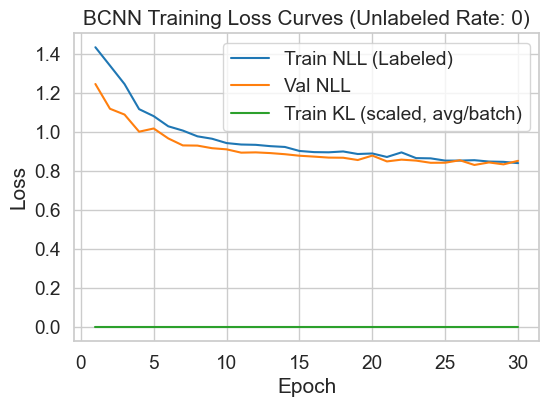

In [51]:
plot_loss_curves_bcnn(upgrade_history_00)

In [58]:
print(f'train nll: {[h["train_nll_labeled"] for h in upgrade_history_00]}')
print(f'val nll: {[h["val_loss"] for h in upgrade_history_00]}')

train nll: [1.4356974434611016, 1.3416262338007332, 1.246837729059954, 1.1182559155968705, 1.082402183935716, 1.0304006163482236, 1.008432358932917, 0.9789575461707068, 0.9666289468711226, 0.9443742143490251, 0.9369847802747006, 0.935360168634918, 0.9285500233585422, 0.9244772148009831, 0.903915215928527, 0.8980121312866848, 0.8970241493125334, 0.901363069199284, 0.8882662570049509, 0.8909862677074796, 0.8730328957330522, 0.8965555016981206, 0.8672715042276085, 0.8660182973466451, 0.854467628089613, 0.8545496601665072, 0.8566107550803138, 0.849630560653091, 0.8481166018166453, 0.8415476145682397]
val nll: [1.2472589385592687, 1.1203482972303869, 1.0905373780463534, 1.002666423351672, 1.0191695619437655, 0.9681823836604239, 0.9323604957888633, 0.9314323351128865, 0.9180948046720396, 0.9122376819907252, 0.8952390181340819, 0.8966734005827253, 0.8930305817191408, 0.887276056221689, 0.8794870260705501, 0.8749140983564428, 0.8699049092717803, 0.8691447909070867, 0.857480604472688, 0.8801465

In [52]:
best_upgrade_00_history = max(upgrade_history_00, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_00_history['epoch']} | Val AUC Macro: {best_upgrade_00_history['val_auc_macro']:.4f}")

best_upgrade_model_00 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_00.load_state_dict(best_upgrade_00_history['model_state'])

Best Epoch: 30 | Val AUC Macro: 0.8733


<All keys matched successfully>

In [53]:
test_results_upgrade_00 = evaluate_bayesian(best_upgrade_model_00, test_loader, device='cpu')
test_results_upgrade_00

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.52it/s]

preds: [5 1 2 ... 5 5 5]


{'macro_auc': 0.8595224509624427,
 'global_auc': 0.9429719549836961,
 'nll': np.float32(0.8499106),
 'per_class_auc': [0.8896729023082814,
  0.8916521188733372,
  0.8526916221033868,
  0.870903347518975,
  0.7958408197571127,
  0.8721856104507515,
  0.8437107357252548],
 'confusion_matrix': array([[0.        , 0.45454545, 0.24242424, 0.        , 0.        ,
         0.3030303 , 0.        ],
        [0.        , 0.46601942, 0.19417476, 0.        , 0.00970874,
         0.33009709, 0.        ],
        [0.        , 0.14090909, 0.37727273, 0.        , 0.04545455,
         0.43636364, 0.        ],
        [0.        , 0.34782609, 0.2173913 , 0.        , 0.        ,
         0.43478261, 0.        ],
        [0.        , 0.02690583, 0.13452915, 0.        , 0.04484305,
         0.79372197, 0.        ],
        [0.        , 0.02311708, 0.02684564, 0.        , 0.00745712,
         0.94258016, 0.        ],
        [0.        , 0.31034483, 0.10344828, 0.        , 0.        ,
         0.5862069 , 0

In [54]:
with torch.no_grad():
    best_upgrade_model_00.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_upgrade_model_00.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:02<00:00,  3.02it/s]

Percentage of predictions that are class 5: 82.9%


In [55]:
best_upgrade_model_00.eval()
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_ssl_loader_00:
        avg_probs = best_upgrade_model_00.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.114 0.233 0.221 0.045 0.105 0.25  0.033]
Class 1: [0.102 0.243 0.213 0.042 0.098 0.263 0.038]
Class 2: [0.062 0.121 0.255 0.024 0.18  0.338 0.019]
Class 3: [0.107 0.225 0.22  0.045 0.099 0.267 0.037]
Class 4: [0.026 0.051 0.162 0.011 0.251 0.485 0.015]
Class 5: [0.015 0.036 0.081 0.008 0.138 0.704 0.017]
Class 6: [0.053 0.155 0.111 0.027 0.114 0.495 0.045]
